In [1]:
!pip install transformers datasets scikit-learn langdetect fastapi uvicorn streamlit -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
df = pd.read_csv(r'C:\Users\User\airline-sentiment\data\Airline Review.csv')

# Drop index duplicate
df = df.drop(columns=['Unnamed: 0'])

# Fix Overall_Rating — it's str dtype, convert carefully
df['Overall_Rating'] = pd.to_numeric(df['Overall_Rating'], errors='coerce')
df = df.dropna(subset=['Overall_Rating', 'Review'])

# Create 3-class sentiment label from Overall_Rating
def rating_to_sentiment(r):
    if r <= 4:   return 'negative'   # label 0
    elif r <= 6: return 'neutral'    # label 1
    else:        return 'positive'   # label 2

df['sentiment'] = df['Overall_Rating'].apply(rating_to_sentiment)
df['label']     = df['sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})

# Combine Review Title + Review for richer text
df['full_text'] = df['Review_Title'].fillna('') + ' ' + df['Review'].fillna('')
df['full_text'] = df['full_text'].str.strip()

# Recommended: convert 'yes'/'no' to binary
df['recommended_binary'] = df['Recommended'].str.lower().map({'yes': 1, 'no': 0})

print(df['sentiment'].value_counts())
print(f"Dataset shape: {df.shape}")

sentiment
negative    16106
positive     4718
neutral      1505
Name: count, dtype: int64
Dataset shape: (22329, 23)


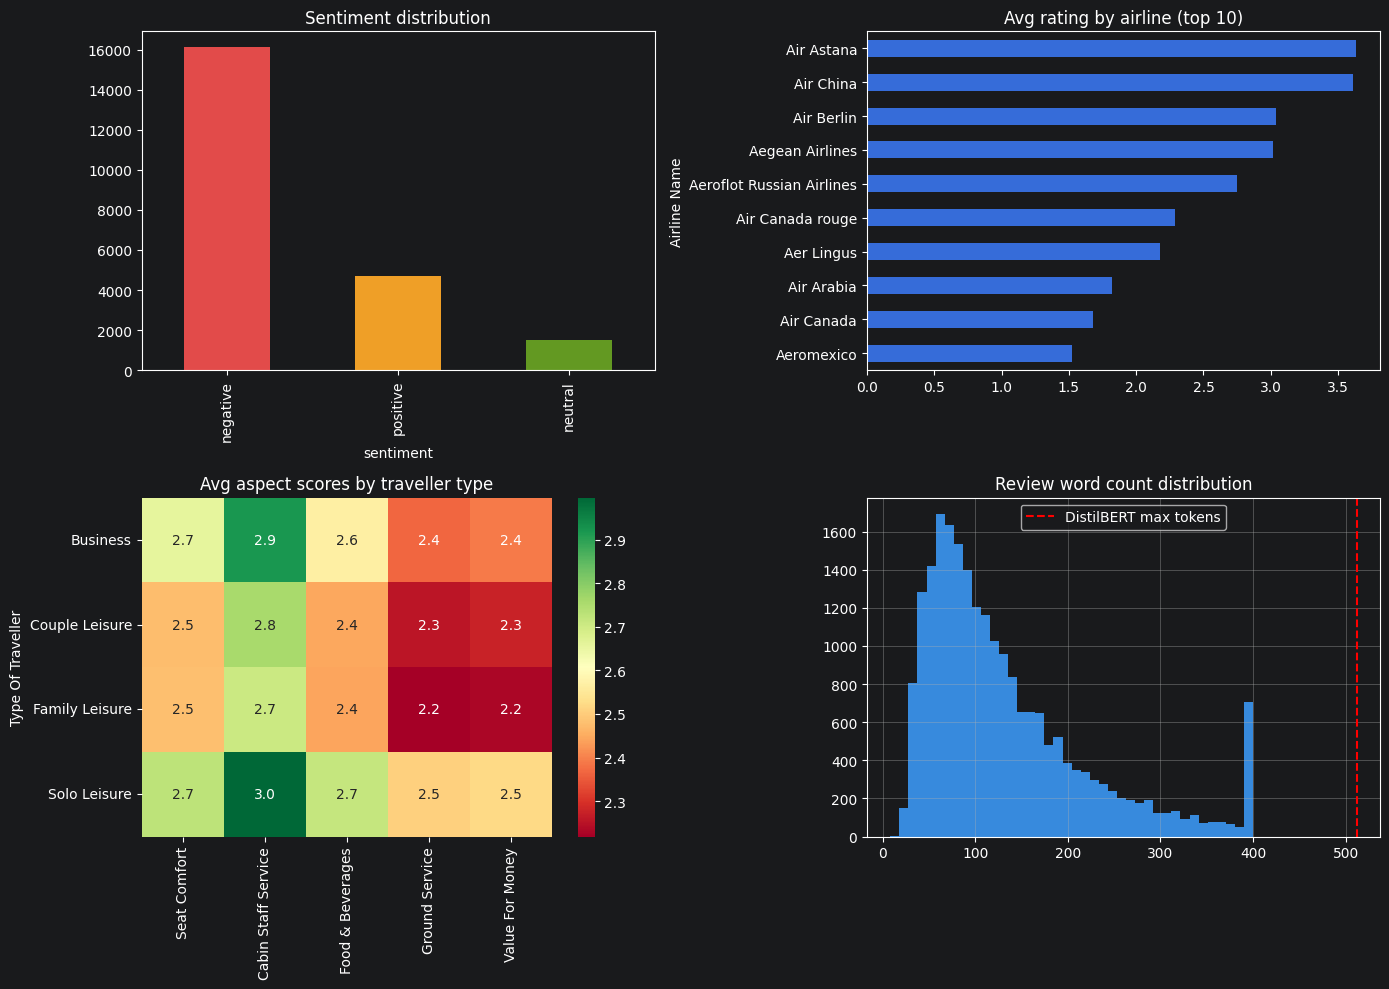

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sentiment distribution
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#E24B4A','#EF9F27','#639922'])
axes[0,0].set_title('Sentiment distribution')

# 2. Rating distribution by airline (top 10)
top_airlines = df['Airline Name'].value_counts().head(10).index
df[df['Airline Name'].isin(top_airlines)].groupby('Airline Name')['Overall_Rating']\
  .mean().sort_values().plot(kind='barh', ax=axes[0,1])
axes[0,1].set_title('Avg rating by airline (top 10)')

# 3. Aspect score heatmap by traveller type
aspect_cols = ['Seat Comfort', 'Cabin Staff Service', 'Food & Beverages',
               'Ground Service', 'Value For Money']
pivot = df.groupby('Type Of Traveller')[aspect_cols].mean().dropna()
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1,0])
axes[1,0].set_title('Avg aspect scores by traveller type')

# 4. Review length distribution
df['review_len'] = df['full_text'].str.split().str.len()
df['review_len'].clip(0, 400).hist(bins=40, ax=axes[1,1], color='#378ADD')
axes[1,1].set_title('Review word count distribution')
axes[1,1].axvline(512, color='red', linestyle='--', label='DistilBERT max tokens')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
import numpy as np

# Split — stratify so each class is balanced across train/val/test
train_df, temp_df = train_test_split(df[['full_text', 'label']],
                    test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42)

In [8]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize(batch):
    return tokenizer(
        batch['full_text'],
        truncation=True,
        padding='max_length',
        max_length=256
    )

In [10]:
train_ds = Dataset.from_pandas(train_df[['full_text', 'label']])
val_ds = Dataset.from_pandas(val_df[['full_text', 'label']])
test_ds = Dataset.from_pandas(test_df[['full_text', 'label']])

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map: 100%|██████████| 2233/2233 [00:00<00:00, 3394.83 examples/s]


ValueError: PyTorch needs to be installed to be able to return PyTorch tensors.

In [11]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)

ImportError: 
DistilBertForSequenceClassification requires the PyTorch library but it was not found in your environment. Check out the instructions on the
installation page: https://pytorch.org/get-started/locally/ and follow the ones that match your environment.
Please note that you may need to restart your runtime after installation.


In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,  # keep low for speed today
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_dir='./logs',
    learning_rate=2e-5,
    load_best_model_at_end=True
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()